In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *

In [3]:
# from examples.case_studies.CITE_seq_analysis import load_data
#
# expression_data, methylation_data, labels = load_data()

In [4]:
sample = np.load('./data/CITE_seq/sample10.npz', allow_pickle=True)
labels, expression_data, methylation_data = sample['labels'], sample['expression_data'], sample['methylation_data']

In [5]:
len(labels), expression_data.shape, methylation_data.shape

(430, (430, 2666), (430, 13))

In [6]:
# train_labels, _, train_expression, _, train_methylation, _ = train_test_split(labels, expression_data, methylation_data,
#                                                                      train_size=0.05, stratify=labels, random_state=42)
# np.savez('./data/CITE_seq/sample10', labels=train_labels, expression_data=train_expression, methylation_data=train_methylation)
# train_labels.shape, train_expression.shape, train_methylation.shape

Text(0.5, 1.0, 'expression_data')

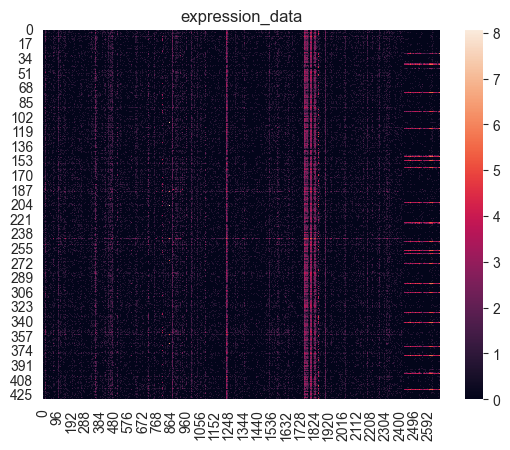

In [7]:
sns.heatmap(expression_data)
plt.title('expression_data')

Text(0.5, 1.0, 'methylation_data')

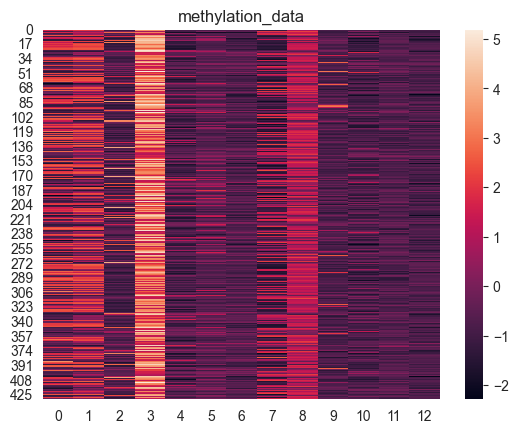

In [8]:
sns.heatmap(methylation_data)
plt.title('methylation_data')

In [9]:
def remove_all_nan_columns(data, remove_all_zeros=True, sigma=0):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(np.abs(data) < 1e-5, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])
    if sigma > 0:
        data = np.exp(data / sigma)
    return data

In [10]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data, sigma=100)

Input #cols 2666
After remove all nan 2666
After remove all zeros 2666
Input #cols 13
After remove all nan 13
After remove all zeros 13


In [11]:
expression_data_clean.min(), expression_data_clean.max()

(np.float64(0.0), np.float64(8.065579427282092))

In [12]:
methylation_data_clean.min(), methylation_data_clean.max()

(np.float64(0.9773716128178341), np.float64(1.0532357250451019))

Text(0.5, 1.0, 'methylation_data_clean')

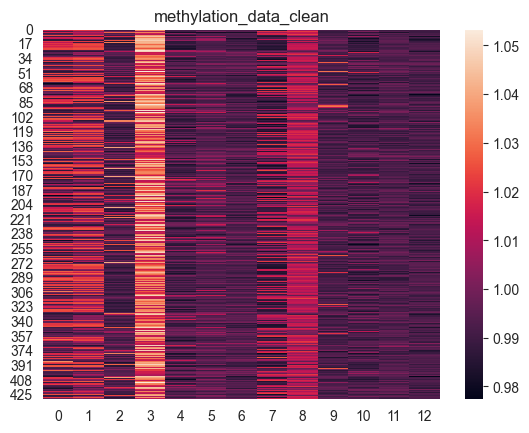

In [13]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

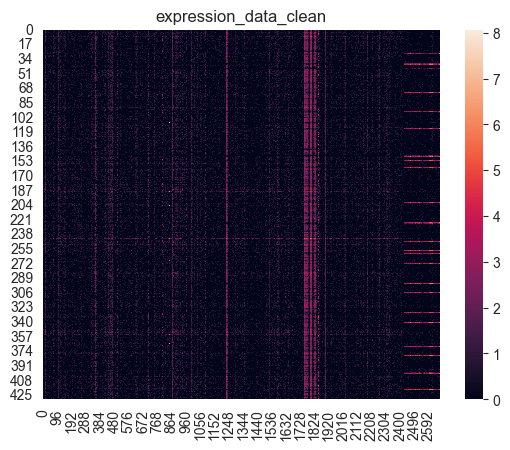

In [14]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [15]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [16]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [17]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((289859, 3), (289859,), (5590, 3), (5590,))

In [18]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [19]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [20]:
weights.min(), weights.max()

(np.float64(0.6931471805599453), np.float64(8.065579427282092))

In [21]:
np.any(np.abs(weights) < 1e-5)

np.False_

In [22]:
edges.shape, weights.shape

((295449, 3), (295449,))

In [23]:
save_edges_and_weights('./data/CITE_seq', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [24]:
train_data = np.load('./data/CITE_seq/train_data.npz', allow_pickle=True)
test_data = np.load('./data/CITE_seq/test_data.npz', allow_pickle=True)

In [25]:
train_data['nums_type']

array([ 430, 2679,    2])

Negative entries cannot be used. BUT WHY?

In [26]:
!python hgnn/main_torch_zinb.py --data CITE_seq --feature adj --loss bce --iter 50 --batch_size 96

1.0 -0.5
model_no_randomwalk
Use train_weight (295449,)
Node type num [ 430 2679    2]
embeddings_initial [np.False_, np.False_, np.False_]
[0.6931472  0.6931472  0.6931472  ... 0.9932345  0.98896503 0.9927252 ] 0.6931472 8.065579
walk type 
adding pad idx
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
dict_size 295449 295449
train data amount 295449
64
tensor([   0,  430, 3109, 3111], device='mps:0')
w.shape (430, 2681)
(430, 2681)
w.shape (2679, 432)
(2679, 432)
w.shape (2, 3109)
(2, 3109)
self.input_size [2681, 432, 3109]
inp 2681 out 64 weight.shape torch.Size([64, 2681])
fan_in 2681 51.778373863998475
inp 432 out 64 weight.shape torch.Size([64, 432])
fan_in 432 20.784609690826528
inp 3109 out 64 weight.shape torch.Size([64, 3109])
fan_in 3109 55.758407437802596
params to be trained 670079
batch size 96
[ Epoch 0 of 50 ]
  - (Training)   bce:  0.6578,

In [33]:
!ls -lh ./*.npy

zsh:1: no matches found: ./*.npy


In [34]:
!mkdir -p ./embeddings/hgnn/CITE_seq

In [35]:
!mv *.npy ./embeddings/hgnn/CITE_seq

zsh:1: no matches found: *.npy


In [30]:
cell_embeddings = np.load('./embeddings/hgnn/CITE_seq/mymodel_0.npy', allow_pickle=True)

In [31]:
cell_embeddings.shape

(430, 64)

{'NMI': 0.556232495313884,
 'ARI': 0.4542892779847306,
 'FMI': 0.5830355964646602}

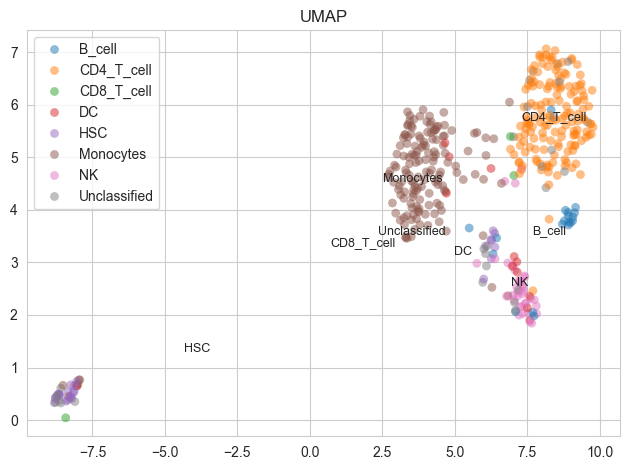

In [32]:
umap_visualize(cell_embeddings, labels)